SHEET METAL BLANK NESTING AND BATCH OPTIMIZATION TOOL

PROCESSING MODE
1 = Single Geometry
2 = Batch Processing


Select processing mode:  1



GEOMETRY 1 INPUT TYPE
1 = Standard Geometry
2 = Manual Coordinate Geometry
3 = DXF Geometry


Select input type:  1



STANDARD GEOMETRY LIST
1  = Rectangle
2  = Right Triangle
3  = General Triangle
4  = Trapezoid
5  = L-Shape
6  = T-Shape
7  = Circle
8  = Ellipse
9  = Regular Polygon
10 = Custom Coordinate Geometry


...


Export consolidated table to CSV? (Y/N):  N



PLOTTING OPTION
1 = Do not plot
2 = Plot best layouts for selected geometries, maximum four
3 = Plot top four layouts for one selected geometry
4 = Create four-geometry comparison figure


Select plotting option:  2



AVAILABLE GEOMETRIES
1 = Right Triangle


Enter up to four geometry numbers separated by commas:  1


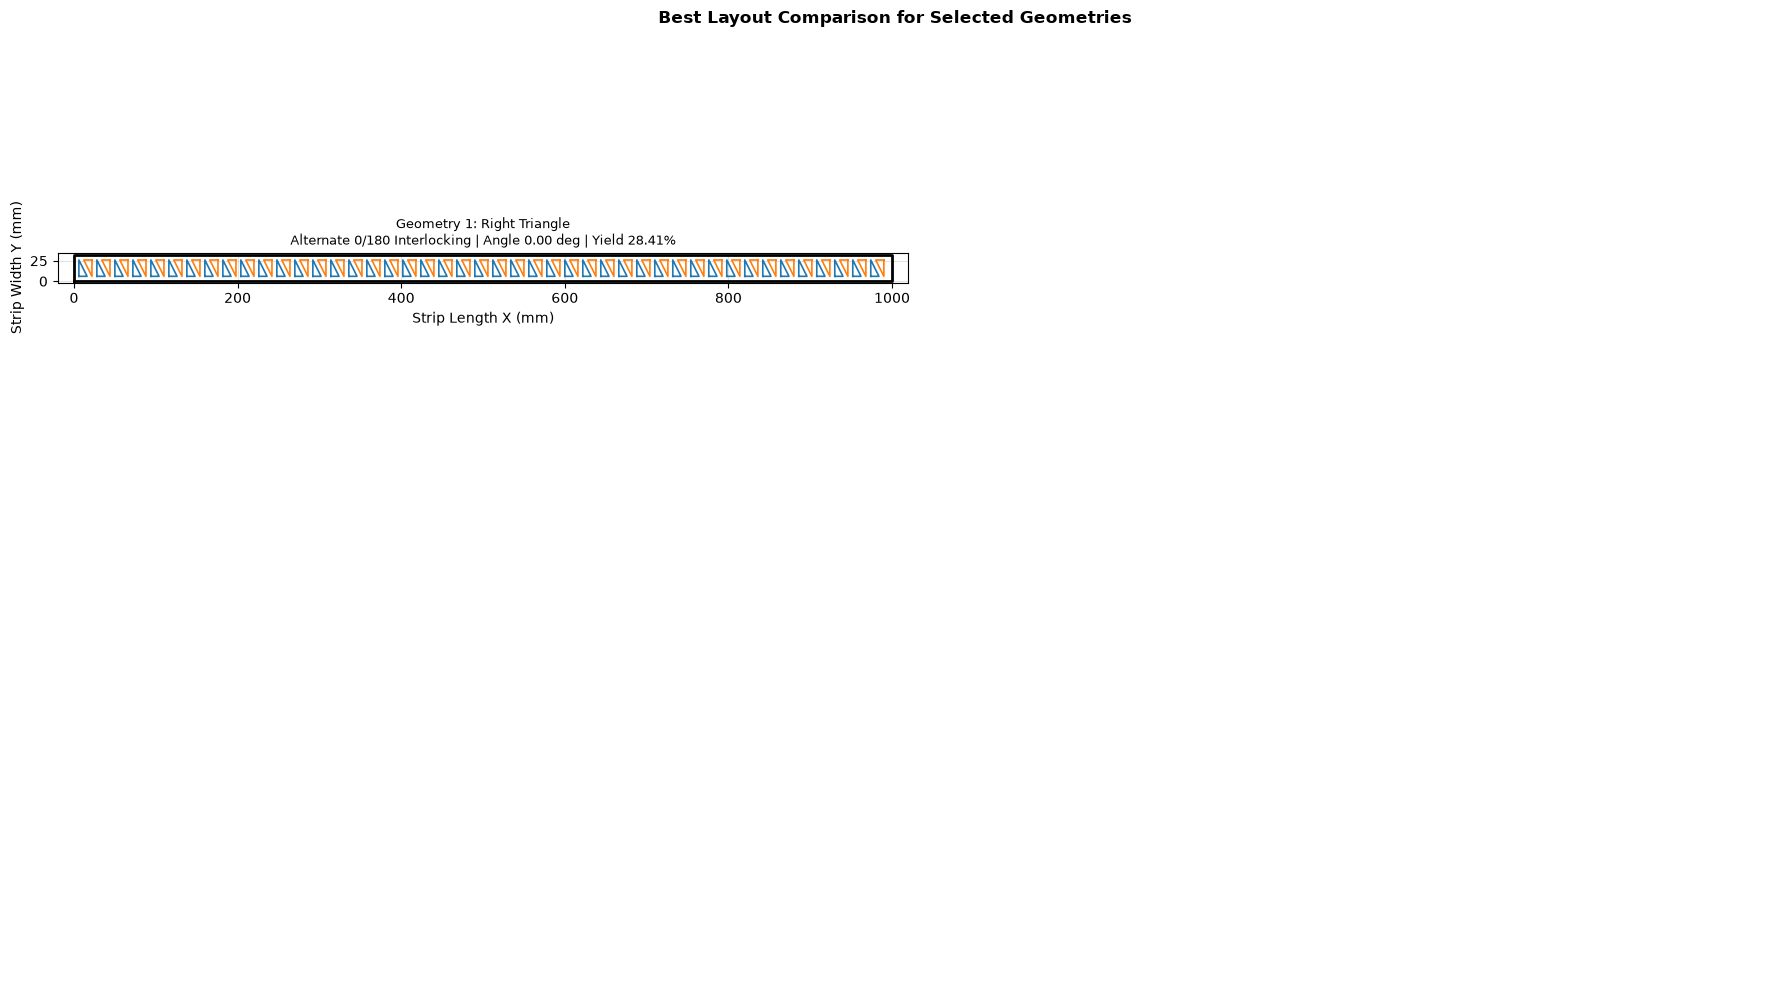


PROCESS COMPLETED


In [1]:
"""
Sheet Metal Blank Nesting Tool - Batch Processing Edition

Features
--------
1. Single-geometry or batch-processing mode.
2. Standard geometries, custom coordinates, and DXF import.
3. Standard geometry coordinates are generated, displayed, and may be edited.
4. Common or geometry-specific nesting parameters.
5. Manual nesting or accelerated coarse-to-fine automatic nesting.
6. Optional mirror-method evaluation.
7. Top four layouts retained for every geometry.
8. Consolidated tabular results.
9. Optional plotting of selected geometries or top-four layouts.

Required packages
-----------------
pip install numpy matplotlib shapely ezdxf pandas
"""

import math
import os
import time
from pathlib import Path

import ezdxf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ezdxf import path as ezpath
from shapely.affinity import rotate, scale, translate
from shapely.geometry import LineString, Polygon
from shapely.ops import polygonize, snap, unary_union


# =====================================================
# CONSTANTS
# =====================================================

OVERLAP_TOLERANCE = 1e-6
DEFAULT_COARSE_STEP = 10.0
DEFAULT_FINE_STEP = 2.0
DEFAULT_FINE_WINDOW = 10.0
DEFAULT_TOP_COARSE_ANGLES = 3


# =====================================================
# SAFE INPUT HELPERS
# =====================================================

def input_int(prompt, minimum=None, maximum=None):
    while True:
        try:
            value = int(input(prompt).strip())
            if minimum is not None and value < minimum:
                raise ValueError
            if maximum is not None and value > maximum:
                raise ValueError
            return value
        except ValueError:
            limits = []
            if minimum is not None:
                limits.append(f">= {minimum}")
            if maximum is not None:
                limits.append(f"<= {maximum}")
            suffix = f" ({', '.join(limits)})" if limits else ""
            print(f"Enter a valid integer{suffix}.")


def input_float(prompt, minimum=None, allow_zero=True):
    while True:
        try:
            value = float(input(prompt).strip())
            if minimum is not None and value < minimum:
                raise ValueError
            if not allow_zero and abs(value) < 1e-12:
                raise ValueError
            return value
        except ValueError:
            print("Enter a valid numerical value.")


def input_yes_no(prompt, default=None):
    while True:
        raw = input(prompt).strip().upper()
        if raw == "" and default is not None:
            return bool(default)
        if raw in {"Y", "YES"}:
            return True
        if raw in {"N", "NO"}:
            return False
        print("Enter Y or N.")


def parse_number_list(text):
    values = []
    for token in text.replace(" ", "").split(","):
        if token:
            values.append(int(token))
    return values


# =====================================================
# BASIC GEOMETRY FUNCTIONS
# =====================================================

def parse_points(text):
    points = []
    for pair in text.strip().split():
        x_value, y_value = map(float, pair.split(","))
        points.append((x_value, y_value))
    return points


def format_points(points):
    return " ".join(f"{x:.6g},{y:.6g}" for x, y in points)


def polygon_area(points):
    area_value = 0.0
    point_count = len(points)
    for index in range(point_count):
        x1, y1 = points[index]
        x2, y2 = points[(index + 1) % point_count]
        area_value += x1 * y2 - y1 * x2
    return abs(area_value) / 2.0


def polygon_signed_area(points):
    area_value = 0.0
    point_count = len(points)
    for index in range(point_count):
        x1, y1 = points[index]
        x2, y2 = points[(index + 1) % point_count]
        area_value += x1 * y2 - y1 * x2
    return area_value / 2.0


def clean_point(point, decimals=6):
    return round(float(point[0]), decimals), round(float(point[1]), decimals)


def remove_consecutive_duplicates(points, tolerance=1e-9):
    cleaned = []
    for point in points:
        if not cleaned or math.dist(point, cleaned[-1]) > tolerance:
            cleaned.append(point)
    if len(cleaned) > 1 and math.dist(cleaned[0], cleaned[-1]) <= tolerance:
        cleaned.pop()
    return cleaned


def create_valid_polygon(points, geometry_name="Geometry"):
    points = remove_consecutive_duplicates(points)
    if len(points) < 3:
        raise ValueError(f"{geometry_name}: at least three unique points are required.")

    polygon = Polygon(points)
    if polygon.is_empty or polygon.area <= 0:
        raise ValueError(f"{geometry_name}: polygon area must be greater than zero.")

    if not polygon.is_valid:
        repaired = polygon.buffer(0)
        if repaired.is_empty or repaired.geom_type != "Polygon" or not repaired.is_valid:
            raise ValueError(f"{geometry_name}: polygon is invalid or self-intersecting.")
        polygon = repaired
        points = list(polygon.exterior.coords)[:-1]

    return polygon, [(float(x), float(y)) for x, y in points]


def normalize_polygon(polygon):
    min_x, min_y, _, _ = polygon.bounds
    return translate(polygon, xoff=-min_x, yoff=-min_y)


def safe_rotate(polygon, angle, origin="centroid"):
    if abs(angle % 360.0) < 1e-9:
        return polygon
    return rotate(polygon, angle, origin=origin)


def rotate_points_90_clockwise(points):
    return [(y, -x) for x, y in points]


def overlap_area(polygon_1, polygon_2):
    return polygon_1.intersection(polygon_2).area


def has_overlap(polygons, tolerance=OVERLAP_TOLERANCE):
    for first_index in range(len(polygons)):
        for second_index in range(first_index + 1, len(polygons)):
            if overlap_area(polygons[first_index], polygons[second_index]) > tolerance:
                return True
    return False


# =====================================================
# STANDARD GEOMETRY GENERATORS
# =====================================================

def circle_points(diameter, segment_length):
    radius = diameter / 2.0
    circumference = 2.0 * math.pi * radius
    segment_count = max(12, int(math.ceil(circumference / segment_length)))
    return [
        (
            radius + radius * math.cos(2.0 * math.pi * i / segment_count),
            radius + radius * math.sin(2.0 * math.pi * i / segment_count),
        )
        for i in range(segment_count)
    ]


def ellipse_points(major_diameter, minor_diameter, segment_length):
    semi_major = major_diameter / 2.0
    semi_minor = minor_diameter / 2.0
    approximate_perimeter = math.pi * (
        3.0 * (semi_major + semi_minor)
        - math.sqrt((3.0 * semi_major + semi_minor) * (semi_major + 3.0 * semi_minor))
    )
    segment_count = max(16, int(math.ceil(approximate_perimeter / segment_length)))
    return [
        (
            semi_major + semi_major * math.cos(2.0 * math.pi * i / segment_count),
            semi_minor + semi_minor * math.sin(2.0 * math.pi * i / segment_count),
        )
        for i in range(segment_count)
    ]


def regular_polygon_points(number_of_sides, size_value, size_mode, start_angle_degrees):
    if number_of_sides < 3:
        raise ValueError("Regular polygon requires at least three sides.")

    if size_mode == 1:  # Circumscribed radius
        radius = size_value
    elif size_mode == 2:  # Inscribed radius
        radius = size_value / math.cos(math.pi / number_of_sides)
    elif size_mode == 3:  # Side length
        radius = size_value / (2.0 * math.sin(math.pi / number_of_sides))
    else:
        raise ValueError("Invalid regular polygon size mode.")

    start_angle = math.radians(start_angle_degrees)
    points = []
    for index in range(number_of_sides):
        angle = start_angle + 2.0 * math.pi * index / number_of_sides
        points.append((radius + radius * math.cos(angle), radius + radius * math.sin(angle)))
    return points


def generate_standard_geometry(shape_number):
    if shape_number == 1:
        length = input_float("Enter rectangle length (mm): ", minimum=0, allow_zero=False)
        width = input_float("Enter rectangle width (mm): ", minimum=0, allow_zero=False)
        return "Rectangle", [(0, 0), (length, 0), (length, width), (0, width)]

    if shape_number == 2:
        base = input_float("Enter right-triangle base (mm): ", minimum=0, allow_zero=False)
        height = input_float("Enter right-triangle height (mm): ", minimum=0, allow_zero=False)
        return "Right Triangle", [(0, 0), (base, 0), (0, height)]

    if shape_number == 3:
        print("Enter the three triangle coordinates.")
        points = []
        for index in range(1, 4):
            points.extend(parse_points(input(f"Point {index} as X,Y: ").strip()))
        if len(points) != 3:
            raise ValueError("Exactly three points are required.")
        return "General Triangle", points

    if shape_number == 4:
        bottom_width = input_float("Enter trapezoid bottom width (mm): ", minimum=0, allow_zero=False)
        top_width = input_float("Enter trapezoid top width (mm): ", minimum=0, allow_zero=False)
        height = input_float("Enter trapezoid height (mm): ", minimum=0, allow_zero=False)
        if top_width > bottom_width:
            print("Top width is greater than bottom width; geometry is still accepted.")
        offset = (bottom_width - top_width) / 2.0
        return "Trapezoid", [(0, 0), (bottom_width, 0), (offset + top_width, height), (offset, height)]

    if shape_number == 5:
        overall_length = input_float("Enter L-shape overall length (mm): ", minimum=0, allow_zero=False)
        overall_height = input_float("Enter L-shape overall height (mm): ", minimum=0, allow_zero=False)
        horizontal_thickness = input_float("Enter horizontal-leg thickness (mm): ", minimum=0, allow_zero=False)
        vertical_thickness = input_float("Enter vertical-leg thickness (mm): ", minimum=0, allow_zero=False)
        if horizontal_thickness >= overall_height or vertical_thickness >= overall_length:
            raise ValueError("Leg thicknesses must be smaller than the overall dimensions.")
        points = [
            (0, 0),
            (overall_length, 0),
            (overall_length, horizontal_thickness),
            (vertical_thickness, horizontal_thickness),
            (vertical_thickness, overall_height),
            (0, overall_height),
        ]
        return "L-Shape", points

    if shape_number == 6:
        overall_width = input_float("Enter T-shape overall width (mm): ", minimum=0, allow_zero=False)
        overall_height = input_float("Enter T-shape overall height (mm): ", minimum=0, allow_zero=False)
        flange_thickness = input_float("Enter top-flange thickness (mm): ", minimum=0, allow_zero=False)
        stem_width = input_float("Enter stem width (mm): ", minimum=0, allow_zero=False)
        if flange_thickness >= overall_height or stem_width >= overall_width:
            raise ValueError("Flange thickness and stem width must be smaller than overall dimensions.")
        left_stem = (overall_width - stem_width) / 2.0
        right_stem = left_stem + stem_width
        points = [
            (0, overall_height - flange_thickness),
            (left_stem, overall_height - flange_thickness),
            (left_stem, 0),
            (right_stem, 0),
            (right_stem, overall_height - flange_thickness),
            (overall_width, overall_height - flange_thickness),
            (overall_width, overall_height),
            (0, overall_height),
        ]
        return "T-Shape", points

    if shape_number == 7:
        diameter = input_float("Enter circle diameter (mm): ", minimum=0, allow_zero=False)
        segment_length = input_float("Enter curve segment length (mm): ", minimum=0, allow_zero=False)
        return "Circle", circle_points(diameter, segment_length)

    if shape_number == 8:
        major_diameter = input_float("Enter ellipse major diameter (mm): ", minimum=0, allow_zero=False)
        minor_diameter = input_float("Enter ellipse minor diameter (mm): ", minimum=0, allow_zero=False)
        segment_length = input_float("Enter curve segment length (mm): ", minimum=0, allow_zero=False)
        return "Ellipse", ellipse_points(major_diameter, minor_diameter, segment_length)

    if shape_number == 9:
        number_of_sides = input_int("Enter number of sides: ", minimum=3)
        print("1 = Circumscribed radius")
        print("2 = Inscribed radius")
        print("3 = Side length")
        size_mode = input_int("Select size definition: ", minimum=1, maximum=3)
        size_value = input_float("Enter size value (mm): ", minimum=0, allow_zero=False)
        start_angle = input_float("Enter starting angle (degrees): ")
        return f"Regular Polygon ({number_of_sides} sides)", regular_polygon_points(
            number_of_sides, size_value, size_mode, start_angle
        )

    if shape_number == 10:
        name = input("Enter custom geometry name: ").strip() or "Custom Coordinate Geometry"
        points = parse_points(input("Enter OUTER points as X,Y pairs: ").strip())
        return name, points

    raise ValueError("Invalid standard geometry selection.")


def preview_and_edit_coordinates(geometry_name, points):
    while True:
        print("\nGENERATED / CURRENT COORDINATES")
        print("-" * 60)
        print(format_points(points))
        print("\nCOORDINATE ACTION")
        print("1 = Accept coordinates")
        print("2 = Replace with manually entered coordinates")
        print("3 = Cancel geometry")
        action = input_int("Select action: ", minimum=1, maximum=3)

        if action == 1:
            polygon, valid_points = create_valid_polygon(points, geometry_name)
            return polygon, valid_points
        if action == 2:
            points = parse_points(input("Enter replacement OUTER points: ").strip())
            continue
        return None, None


# =====================================================
# DXF IMPORT FUNCTIONS
# =====================================================

def normalize_dxf_path(dxf_file_path):
    dxf_file_path = dxf_file_path.strip().strip('"').strip("'")
    if not dxf_file_path.lower().endswith(".dxf"):
        dxf_file_path += ".dxf"
    if not os.path.exists(dxf_file_path):
        raise FileNotFoundError(f"DXF file not found: {dxf_file_path}")
    return dxf_file_path


def lwpolyline_has_bulge(entity):
    for point in entity.get_points(format="xyseb"):
        if abs(float(point[4])) > 1e-9:
            return True
    return False


def polyline_has_bulge(entity):
    try:
        vertices = entity.vertices
        if callable(vertices):
            vertices = vertices()
        return any(abs(float(getattr(vertex.dxf, "bulge", 0.0))) > 1e-9 for vertex in vertices)
    except Exception:
        return False


def dxf_has_curved_geometry(dxf_file_path):
    document = ezdxf.readfile(dxf_file_path)
    modelspace = document.modelspace()
    curved_types = {"ARC", "CIRCLE", "ELLIPSE", "SPLINE"}
    for entity in modelspace:
        entity_type = entity.dxftype()
        if entity_type in curved_types:
            return True
        if entity_type == "LWPOLYLINE" and lwpolyline_has_bulge(entity):
            return True
        if entity_type == "POLYLINE" and polyline_has_bulge(entity):
            return True
    return False


def extract_lwpolyline_points(entity):
    if lwpolyline_has_bulge(entity):
        return None
    points = [clean_point((p[0], p[1])) for p in entity.get_points(format="xy")]
    return remove_consecutive_duplicates(points)


def extract_polyline_points(entity):
    if polyline_has_bulge(entity):
        return None
    vertices = entity.vertices
    if callable(vertices):
        vertices = vertices()
    points = [clean_point((v.dxf.location.x, v.dxf.location.y)) for v in vertices]
    return remove_consecutive_duplicates(points)


def build_closed_loop_from_lines(line_segments, tolerance=1e-5):
    if not line_segments:
        return None

    unused = list(line_segments)
    start_segment = unused.pop(0)
    loop = [start_segment[0], start_segment[1]]
    start_point = loop[0]

    while unused:
        current_end = loop[-1]
        if math.dist(current_end, start_point) <= tolerance and len(loop) >= 4:
            loop[-1] = start_point
            break

        found = None
        for index, (point_1, point_2) in enumerate(unused):
            if math.dist(point_1, current_end) <= tolerance:
                found = (index, point_2)
                break
            if math.dist(point_2, current_end) <= tolerance:
                found = (index, point_1)
                break

        if found is None:
            break
        index, next_point = found
        unused.pop(index)
        loop.append(next_point)

    if math.dist(loop[-1], start_point) > tolerance:
        return None
    loop[-1] = start_point
    return remove_consecutive_duplicates(loop)


def import_simple_outer_points_from_dxf(dxf_file_path):
    document = ezdxf.readfile(dxf_file_path)
    modelspace = document.modelspace()
    candidates = []

    for entity in modelspace.query("LWPOLYLINE"):
        if entity.closed:
            points = extract_lwpolyline_points(entity)
            if points and len(points) >= 3:
                candidates.append(points)

    for entity in modelspace.query("POLYLINE"):
        closed = entity.is_closed() if callable(entity.is_closed) else entity.is_closed
        if closed:
            points = extract_polyline_points(entity)
            if points and len(points) >= 3:
                candidates.append(points)

    if not candidates:
        segments = []
        for entity in modelspace.query("LINE"):
            start = entity.dxf.start
            end = entity.dxf.end
            segments.append((clean_point((start.x, start.y)), clean_point((end.x, end.y))))
        points = build_closed_loop_from_lines(segments)
        if points:
            candidates.append(points)

    if not candidates:
        raise ValueError("No valid closed straight-line DXF boundary was found.")

    return max(candidates, key=lambda pts: abs(polygon_signed_area(pts)))


def entity_is_closed_like(entity):
    entity_type = entity.dxftype()
    if entity_type in {"CIRCLE", "ELLIPSE"}:
        return True
    if entity_type == "LWPOLYLINE":
        return bool(entity.closed)
    if entity_type == "POLYLINE":
        return bool(entity.is_closed() if callable(entity.is_closed) else entity.is_closed)
    return False


def resample_points(points, maximum_segment_length):
    if len(points) < 2:
        return points
    output = [points[0]]
    for start, end in zip(points[:-1], points[1:]):
        distance = math.dist(start, end)
        subdivisions = max(1, int(math.ceil(distance / maximum_segment_length)))
        for index in range(1, subdivisions + 1):
            fraction = index / subdivisions
            output.append(
                clean_point(
                    (
                        start[0] + fraction * (end[0] - start[0]),
                        start[1] + fraction * (end[1] - start[1]),
                    )
                )
            )
    return output


def entity_to_points_using_path(entity, segment_length, closing_tolerance):
    try:
        path_object = ezpath.make_path(entity)
        flatten_distance = max(segment_length / 2.0, 0.05)
        points = [clean_point((v.x, v.y)) for v in path_object.flattening(distance=flatten_distance)]
        if len(points) < 2:
            return []
        if entity_is_closed_like(entity) and points[0] != points[-1]:
            points.append(points[0])
        elif math.dist(points[0], points[-1]) <= closing_tolerance:
            points[-1] = points[0]
        return resample_points(points, segment_length)
    except Exception:
        return []


def import_complex_outer_points_from_dxf(dxf_file_path, segment_length, closing_tolerance=None):
    if closing_tolerance is None:
        closing_tolerance = max(segment_length * 1.5, 0.5)

    document = ezdxf.readfile(dxf_file_path)
    modelspace = document.modelspace()
    supported = {"LINE", "LWPOLYLINE", "POLYLINE", "ARC", "CIRCLE", "ELLIPSE", "SPLINE"}
    lines = []
    polygon_candidates = []

    for entity in modelspace:
        entity_type = entity.dxftype()
        if entity_type not in supported:
            continue

        if entity_type == "LINE":
            start = entity.dxf.start
            end = entity.dxf.end
            lines.append(LineString([(start.x, start.y), (end.x, end.y)]))
            continue

        points = entity_to_points_using_path(entity, segment_length, closing_tolerance)
        if len(points) < 2:
            continue
        line = LineString(points)
        lines.append(line)
        if points[0] == points[-1] and len(points) >= 4:
            candidate = Polygon(points[:-1])
            if candidate.is_valid and candidate.area > 0:
                polygon_candidates.append(candidate)

    if lines:
        merged = unary_union(lines)
        snapped = snap(merged, merged, closing_tolerance)
        polygon_candidates.extend(
            polygon for polygon in polygonize(unary_union(snapped))
            if polygon.is_valid and polygon.area > 0
        )

    if not polygon_candidates:
        raise ValueError(
            "No closed polygon could be created from the DXF geometry. "
            "Check entity connectivity or increase segment/closing tolerance."
        )

    outer_polygon = max(polygon_candidates, key=lambda polygon: polygon.area)
    return [(float(x), float(y)) for x, y in list(outer_polygon.exterior.coords)[:-1]]


def input_dxf_geometry(default_name):
    dxf_file = normalize_dxf_path(input("Enter DXF file path: ").strip())
    segment_length = input_float("Enter DXF segment length (mm), e.g. 1.0 or 2.0: ", minimum=0, allow_zero=False)
    curved = dxf_has_curved_geometry(dxf_file)

    if curved:
        print("Curved DXF entities detected; complex conversion will be used.")
        points = import_complex_outer_points_from_dxf(dxf_file, segment_length)
    else:
        try:
            points = import_simple_outer_points_from_dxf(dxf_file)
            print("Straight-line DXF imported without curve discretization.")
        except Exception:
            print("Simple DXF import failed; robust complex conversion will be used.")
            points = import_complex_outer_points_from_dxf(dxf_file, segment_length)

    name = input(f"Enter geometry name [{Path(dxf_file).stem}]: ").strip() or Path(dxf_file).stem or default_name
    polygon, points = create_valid_polygon(points, name)
    return {
        "name": name,
        "input_type": "DXF",
        "source": dxf_file,
        "segment_length": segment_length,
        "points": points,
        "polygon": polygon,
        "area": polygon.area,
    }


# =====================================================
# GEOMETRY ENTRY MANAGEMENT
# =====================================================

def input_standard_geometry(default_name):
    print("\nSTANDARD GEOMETRY LIST")
    print("1  = Rectangle")
    print("2  = Right Triangle")
    print("3  = General Triangle")
    print("4  = Trapezoid")
    print("5  = L-Shape")
    print("6  = T-Shape")
    print("7  = Circle")
    print("8  = Ellipse")
    print("9  = Regular Polygon")
    print("10 = Custom Coordinate Geometry")

    shape_number = input_int("Select standard geometry: ", minimum=1, maximum=10)
    suggested_name, points = generate_standard_geometry(shape_number)
    name = input(f"Enter geometry name [{suggested_name}]: ").strip() or suggested_name or default_name
    polygon, points = preview_and_edit_coordinates(name, points)
    if polygon is None:
        return None

    return {
        "name": name,
        "input_type": "Standard/Coordinates",
        "source": suggested_name,
        "segment_length": None,
        "points": points,
        "polygon": polygon,
        "area": polygon.area,
    }


def input_manual_coordinate_geometry(default_name):
    name = input(f"Enter geometry name [{default_name}]: ").strip() or default_name
    points = parse_points(input("Enter OUTER points as space-separated X,Y pairs: ").strip())
    polygon, points = preview_and_edit_coordinates(name, points)
    if polygon is None:
        return None
    return {
        "name": name,
        "input_type": "Manual Coordinates",
        "source": "Manual",
        "segment_length": None,
        "points": points,
        "polygon": polygon,
        "area": polygon.area,
    }


def input_geometry_entry(index):
    print(f"\nGEOMETRY {index} INPUT TYPE")
    print("1 = Standard Geometry")
    print("2 = Manual Coordinate Geometry")
    print("3 = DXF Geometry")
    input_type = input_int("Select input type: ", minimum=1, maximum=3)

    if input_type == 1:
        return input_standard_geometry(f"Geometry {index}")
    if input_type == 2:
        return input_manual_coordinate_geometry(f"Geometry {index}")
    return input_dxf_geometry(f"Geometry {index}")


def print_geometry_summary(geometries):
    rows = []
    for index, geometry in enumerate(geometries, start=1):
        rows.append(
            {
                "No.": index,
                "Geometry": geometry["name"],
                "Input Type": geometry["input_type"],
                "Points": len(geometry["points"]),
                "Area (mm2)": round(geometry["area"], 3),
            }
        )
    frame = pd.DataFrame(rows)
    print("\nBATCH GEOMETRY SUMMARY")
    print("-" * 90)
    print(frame.to_string(index=False))


# =====================================================
# NESTING CORE
# =====================================================

def find_minimum_close_pitch(polygon, x_gap, step, tolerance=OVERLAP_TOLERANCE):
    min_x, _, max_x, _ = polygon.bounds
    bounding_length = max_x - min_x
    pitch = bounding_length
    last_safe_pitch = bounding_length

    while pitch >= 0:
        moved = translate(polygon, xoff=pitch)
        if overlap_area(polygon, moved) > tolerance:
            break
        last_safe_pitch = pitch
        pitch -= step
    return max(0.0, last_safe_pitch) + x_gap


def find_minimum_pitch_between(left_polygon, right_polygon, x_gap, step, tolerance=OVERLAP_TOLERANCE):
    min_x, _, max_x, _ = left_polygon.bounds
    left_width = max_x - min_x
    pitch = left_width
    last_safe_pitch = left_width

    while pitch >= 0:
        moved_right = translate(right_polygon, xoff=pitch)
        if overlap_area(left_polygon, moved_right) > tolerance:
            break
        last_safe_pitch = pitch
        pitch -= step
    return max(0.0, last_safe_pitch) + x_gap


def evaluate_single_nesting(polygon, blank_area, parameters, method, pitch_step):
    polygon = normalize_polygon(polygon)
    min_x, min_y, max_x, max_y = polygon.bounds
    part_length = max_x - min_x
    part_height = max_y - min_y

    if method == "BOUNDING":
        pitch_x = part_length + parameters["x_gap"]
    else:
        pitch_x = find_minimum_close_pitch(polygon, parameters["x_gap"], pitch_step)

    strip_width = (
        parameters["bottom_offset"]
        + parameters["num_rows"] * part_height
        + (parameters["num_rows"] - 1) * parameters["row_gap"]
        + parameters["top_offset"]
    )

    quantity_per_row = 0
    current_x = parameters["origin_x"]
    while current_x + part_length <= parameters["strip_length"] + 1e-9:
        quantity_per_row += 1
        current_x += pitch_x

    if quantity_per_row == 0:
        return None

    placed = []
    for row_index in range(parameters["num_rows"]):
        row_y = parameters["bottom_offset"] + row_index * (part_height + parameters["row_gap"])
        for column_index in range(quantity_per_row):
            x_shift = parameters["origin_x"] + column_index * pitch_x
            placed.append(translate(polygon, xoff=x_shift, yoff=row_y))

    if has_overlap(placed):
        return None

    total_quantity = quantity_per_row * parameters["num_rows"]
    used_length = parameters["origin_x"] + (quantity_per_row - 1) * pitch_x + part_length
    input_area = used_length * strip_width
    yield_percentage = 100.0 * total_quantity * blank_area / input_area if input_area > 0 else 0.0

    return {
        "part_length": part_length,
        "part_height": part_height,
        "pitch_x": pitch_x,
        "strip_width": strip_width,
        "qty_per_row": quantity_per_row,
        "total_qty": total_quantity,
        "used_strip_length": used_length,
        "input_strip_area": input_area,
        "utilized_blank_area": total_quantity * blank_area,
        "yield_pct": yield_percentage,
        "placed_polygons": placed,
    }


def evaluate_pair_nesting(polygon_a, polygon_b, angle, blank_area, parameters, pitch_step):
    polygon_a = normalize_polygon(polygon_a)
    polygon_b = normalize_polygon(polygon_b)

    min_x_a, _, max_x_a, max_y_a = polygon_a.bounds
    _, min_y_a, _, _ = polygon_a.bounds
    min_x_b, _, max_x_b, max_y_b = polygon_b.bounds
    _, min_y_b, _, _ = polygon_b.bounds

    length_a = max_x_a - min_x_a
    length_b = max_x_b - min_x_b
    height_a = max_y_a - min_y_a
    height_b = max_y_b - min_y_b
    part_height = max(height_a, height_b)

    pitch_ab = find_minimum_pitch_between(polygon_a, polygon_b, parameters["x_gap"], pitch_step)
    pitch_ba = find_minimum_pitch_between(polygon_b, polygon_a, parameters["x_gap"], pitch_step)

    strip_width = (
        parameters["bottom_offset"]
        + parameters["num_rows"] * part_height
        + (parameters["num_rows"] - 1) * parameters["row_gap"]
        + parameters["top_offset"]
    )

    placed = []
    placed_types = []
    quantity_per_row = 0

    for row_index in range(parameters["num_rows"]):
        row_y = parameters["bottom_offset"] + row_index * (part_height + parameters["row_gap"])
        x_position = parameters["origin_x"]
        column_index = 0

        while True:
            if column_index % 2 == 0:
                current_polygon, current_length, current_type = polygon_a, length_a, "A"
            else:
                current_polygon, current_length, current_type = polygon_b, length_b, "B"

            if x_position + current_length > parameters["strip_length"] + 1e-9:
                break

            placed.append(translate(current_polygon, xoff=x_position, yoff=row_y))
            placed_types.append(current_type)
            if row_index == 0:
                quantity_per_row += 1

            x_position += pitch_ab if column_index % 2 == 0 else pitch_ba
            column_index += 1

    total_quantity = quantity_per_row * parameters["num_rows"]
    if total_quantity == 0 or has_overlap(placed):
        return None

    used_length = max(polygon.bounds[2] for polygon in placed)
    input_area = used_length * strip_width
    yield_percentage = 100.0 * total_quantity * blank_area / input_area if input_area > 0 else 0.0

    return {
        "part_length": max(length_a, length_b),
        "part_height": part_height,
        "pitch_x": (pitch_ab + pitch_ba) / 2.0,
        "pitch_ab": pitch_ab,
        "pitch_ba": pitch_ba,
        "strip_width": strip_width,
        "qty_per_row": quantity_per_row,
        "total_qty": total_quantity,
        "used_strip_length": used_length,
        "input_strip_area": input_area,
        "utilized_blank_area": total_quantity * blank_area,
        "yield_pct": yield_percentage,
        "placed_polygons": placed,
        "placed_types": placed_types,
        "angle": angle,
    }


def get_longest_edge(polygon):
    coordinates = list(polygon.exterior.coords)
    best_line = None
    best_length = 0.0
    best_angle = 0.0
    for start, end in zip(coordinates[:-1], coordinates[1:]):
        line = LineString([start, end])
        if line.length > best_length:
            best_line = line
            best_length = line.length
            best_angle = math.degrees(math.atan2(end[1] - start[1], end[0] - start[0])) % 180.0
    return best_line, best_length, best_angle


def longest_edge_alignment(polygon_1, polygon_2, parallel_tolerance=5.0):
    edge_1, length_1, angle_1 = get_longest_edge(polygon_1)
    edge_2, length_2, angle_2 = get_longest_edge(polygon_2)
    difference = abs(angle_1 - angle_2)
    if difference > 90.0:
        difference = 180.0 - difference
    return {
        "long_edge_gap": edge_1.distance(edge_2),
        "long_edge_a": length_1,
        "long_edge_b": length_2,
        "long_edge_angle_a": angle_1,
        "long_edge_angle_b": angle_2,
        "long_edge_angle_diff": difference,
        "long_edge_parallel": difference <= parallel_tolerance,
    }


def run_bounding_method(geometry, parameters, pitch_step, prefix=""):
    polygon = geometry["polygon"]
    min_x, min_y, max_x, max_y = polygon.bounds
    if max_y - min_y > max_x - min_x:
        polygon = rotate(polygon, -90, origin="centroid")

    result = evaluate_single_nesting(polygon, geometry["area"], parameters, "BOUNDING", pitch_step)
    if result:
        result.update(
            method_no=1,
            method_name="Bounding Box",
            angle=0.0,
            mirror_direction=None,
            display_name=f"{prefix}Method 1 - Bounding Box".strip(),
        )
    return result


def run_rotated_method(geometry, angle, parameters, pitch_step, prefix=""):
    polygon = safe_rotate(geometry["polygon"], angle, origin="centroid")
    result = evaluate_single_nesting(polygon, geometry["area"], parameters, "ROTATED", pitch_step)
    if result:
        result.update(
            method_no=2,
            method_name="Rotated Close-Stack",
            angle=float(angle),
            mirror_direction=None,
            display_name=f"{prefix}Method 2 - Rotated {angle:.2f} deg".strip(),
        )
    return result


def run_alternate_method(geometry, angle, parameters, pitch_step, prefix=""):
    polygon_a = safe_rotate(geometry["polygon"], angle, origin="centroid")
    polygon_b = safe_rotate(geometry["polygon"], angle + 180.0, origin="centroid")
    result = evaluate_pair_nesting(polygon_a, polygon_b, angle, geometry["area"], parameters, pitch_step)
    if result:
        result.update(
            method_no=3,
            method_name="Alternate 0/180 Interlocking",
            angle=float(angle),
            mirror_direction=None,
            display_name=f"{prefix}Method 3 - Alternate 0/180, Base {angle:.2f} deg".strip(),
        )
    return result


def run_mirror_method(geometry, angle, mirror_direction, parameters, pitch_step, prefix=""):
    polygon_a = safe_rotate(geometry["polygon"], angle, origin="centroid")
    if mirror_direction == 1:
        polygon_b = scale(polygon_a, xfact=-1, yfact=1, origin="centroid")
        mirror_text = "Vertical Mirror"
    else:
        polygon_b = scale(polygon_a, xfact=1, yfact=-1, origin="centroid")
        mirror_text = "Horizontal Mirror"

    result = evaluate_pair_nesting(polygon_a, polygon_b, angle, geometry["area"], parameters, pitch_step)
    if result and result["qty_per_row"] >= 2:
        edge_data = longest_edge_alignment(result["placed_polygons"][0], result["placed_polygons"][1])
        result.update(edge_data)
        result.update(
            method_no=4,
            method_name="Mirror Pair Nesting",
            angle=float(angle),
            mirror_direction=mirror_direction,
            mirror_text=mirror_text,
            display_name=f"{prefix}Method 4 - {mirror_text}, Angle {angle:.2f} deg".strip(),
        )
        return result
    return None


def result_sort_key(result):
    return (
        result["yield_pct"],
        result["total_qty"],
        -result["used_strip_length"],
        -result["pitch_x"],
    )


def make_fine_angle_list(center_angle, maximum_angle, fine_step=2.0, fine_window=10.0):
    angles = []
    value = center_angle - fine_window
    while value <= center_angle + fine_window + 1e-9:
        if maximum_angle == 360:
            angles.append(round(value % 360.0, 6))
        elif 0 <= value < maximum_angle:
            angles.append(round(value, 6))
        value += fine_step
    return sorted(set(angles))


def best_center_angles(results, top_n=DEFAULT_TOP_COARSE_ANGLES):
    return [result["angle"] for result in sorted(results, key=result_sort_key, reverse=True)[:top_n]]


def coarse_to_fine_search(run_function, maximum_angle, coarse_step, fine_step, fine_window, top_n):
    results = []
    counters = {"total": 0, "valid": 0, "invalid": 0}
    evaluated = set()
    coarse_results = []

    for angle in np.arange(0, maximum_angle, coarse_step):
        angle = float(angle)
        evaluated.add(round(angle, 6))
        counters["total"] += 1
        result = run_function(angle, "Auto Coarse ")
        if result:
            coarse_results.append(result)
            results.append(result)
            counters["valid"] += 1
        else:
            counters["invalid"] += 1

    fine_angles = []
    for center in best_center_angles(coarse_results, top_n):
        fine_angles.extend(make_fine_angle_list(center, maximum_angle, fine_step, fine_window))

    for angle in sorted(set(fine_angles)):
        if round(angle, 6) in evaluated:
            continue
        evaluated.add(round(angle, 6))
        counters["total"] += 1
        result = run_function(angle, "Auto Fine ")
        if result:
            results.append(result)
            counters["valid"] += 1
        else:
            counters["invalid"] += 1

    return results, counters


def combine_counters(target, addition):
    for key in target:
        target[key] += addition[key]


# =====================================================
# NESTING PARAMETER INPUT
# =====================================================

def input_nesting_parameters(title="NESTING PARAMETERS"):
    print(f"\n{title}")
    print("-" * 50)
    num_rows = input_int("Enter number of rows: ", minimum=1)
    origin_x = input_float("Enter X offset from vertical strip datum (mm): ", minimum=0)
    bottom_offset = input_float("Enter bottom offset (mm): ", minimum=0)
    top_offset = input_float("Enter top offset (mm): ", minimum=0)
    x_gap = input_float("Enter minimum X gap between blanks (mm): ", minimum=0)
    row_gap = input_float("Enter row gap (mm): ", minimum=0) if num_rows > 1 else 0.0
    strip_length = input_float("Enter available strip length (mm): ", minimum=0, allow_zero=False)
    return {
        "num_rows": num_rows,
        "origin_x": origin_x,
        "bottom_offset": bottom_offset,
        "top_offset": top_offset,
        "x_gap": x_gap,
        "row_gap": row_gap,
        "strip_length": strip_length,
    }


def input_run_settings():
    print("\nNESTING RUN MODE")
    print("1 = Manual Nesting")
    print("2 = Auto Nesting with coarse-to-fine search")
    run_mode = input_int("Select run mode: ", minimum=1, maximum=2)

    print("\nPITCH SEARCH STEP")
    print("0.5 mm = detailed, 1.0 mm = balanced, 2.0 mm = fast")
    pitch_step = input_float("Enter pitch search step (mm): ", minimum=0, allow_zero=False)

    settings = {
        "run_mode": run_mode,
        "pitch_step": pitch_step,
        "include_mirror": True,
        "coarse_step": DEFAULT_COARSE_STEP,
        "fine_step": DEFAULT_FINE_STEP,
        "fine_window": DEFAULT_FINE_WINDOW,
        "top_coarse_angles": DEFAULT_TOP_COARSE_ANGLES,
    }

    if run_mode == 1:
        print("1 = Bounding Box")
        print("2 = Rotated Close-Stack")
        print("3 = Alternate 0/180")
        print("4 = Mirror Pair")
        settings["manual_method"] = input_int("Select manual method: ", minimum=1, maximum=4)
        if settings["manual_method"] in {2, 3, 4}:
            settings["manual_angle_interval"] = input_float(
                "Enter angle interval in degrees (0 means only 0 degree): ", minimum=0
            )
        if settings["manual_method"] == 4:
            print("1 = Vertical mirror")
            print("2 = Horizontal mirror")
            print("3 = Both")
            settings["manual_mirror_choice"] = input_int("Select mirror option: ", minimum=1, maximum=3)
    else:
        settings["include_mirror"] = input_yes_no("Include mirror method in automatic nesting? (Y/N): ")

    return settings


# =====================================================
# RUN NESTING FOR ONE GEOMETRY
# =====================================================

def run_geometry_nesting(geometry, parameters, settings):
    results = []
    counters = {"total": 0, "valid": 0, "invalid": 0}
    start_time = time.perf_counter()
    pitch_step = settings["pitch_step"]

    def add_result(result):
        counters["total"] += 1
        if result:
            results.append(result)
            counters["valid"] += 1
        else:
            counters["invalid"] += 1

    if settings["run_mode"] == 1:
        method = settings["manual_method"]
        if method == 1:
            add_result(run_bounding_method(geometry, parameters, pitch_step, "Manual "))

        elif method == 2:
            interval = settings["manual_angle_interval"]
            angles = [0.0] if interval == 0 else np.arange(0, 360, interval)
            for angle in angles:
                add_result(run_rotated_method(geometry, float(angle), parameters, pitch_step, "Manual "))

        elif method == 3:
            interval = settings["manual_angle_interval"]
            angles = [0.0] if interval == 0 else np.arange(0, 180, interval)
            for angle in angles:
                add_result(run_alternate_method(geometry, float(angle), parameters, pitch_step, "Manual "))

        else:
            choice = settings["manual_mirror_choice"]
            directions = [1] if choice == 1 else [2] if choice == 2 else [1, 2]
            interval = settings["manual_angle_interval"]
            angles = [0.0] if interval == 0 else np.arange(0, 360, interval)
            for direction in directions:
                for angle in angles:
                    add_result(run_mirror_method(geometry, float(angle), direction, parameters, pitch_step, "Manual "))

    else:
        add_result(run_bounding_method(geometry, parameters, pitch_step, "Auto "))

        rotated_results, rotated_counts = coarse_to_fine_search(
            lambda angle, prefix: run_rotated_method(geometry, angle, parameters, pitch_step, prefix),
            360,
            settings["coarse_step"],
            settings["fine_step"],
            settings["fine_window"],
            settings["top_coarse_angles"],
        )
        results.extend(rotated_results)
        combine_counters(counters, rotated_counts)

        alternate_results, alternate_counts = coarse_to_fine_search(
            lambda angle, prefix: run_alternate_method(geometry, angle, parameters, pitch_step, prefix),
            180,
            settings["coarse_step"],
            settings["fine_step"],
            settings["fine_window"],
            settings["top_coarse_angles"],
        )
        results.extend(alternate_results)
        combine_counters(counters, alternate_counts)

        if settings["include_mirror"]:
            for direction in [1, 2]:
                mirror_results, mirror_counts = coarse_to_fine_search(
                    lambda angle, prefix, d=direction: run_mirror_method(
                        geometry, angle, d, parameters, pitch_step, prefix
                    ),
                    360,
                    settings["coarse_step"],
                    settings["fine_step"],
                    settings["fine_window"],
                    settings["top_coarse_angles"],
                )
                results.extend(mirror_results)
                combine_counters(counters, mirror_counts)

    elapsed = time.perf_counter() - start_time
    results = sorted(results, key=result_sort_key, reverse=True)
    for result in results:
        result["execution_time_sec"] = elapsed
    return results, counters, elapsed


# =====================================================
# RESULTS AND PLOTTING
# =====================================================

def result_rows_for_geometry(geometry_number, geometry, results, top_n=4):
    rows = []
    for rank, result in enumerate(results[:top_n], start=1):
        rows.append(
            {
                "Geometry No.": geometry_number,
                "Geometry Name": geometry["name"],
                "Input Type": geometry["input_type"],
                "Rank": rank,
                "Method": result["method_name"],
                "Method Details": result["display_name"],
                "Angle (deg)": round(result["angle"], 3),
                "Quantity": result["total_qty"],
                "Pitch (mm)": round(result["pitch_x"], 3),
                "Strip Width (mm)": round(result["strip_width"], 3),
                "Used Length (mm)": round(result["used_strip_length"], 3),
                "Yield (%)": round(result["yield_pct"], 3),
                "Scrap (%)": round(100.0 - result["yield_pct"], 3),
                "Blank Area (mm2)": round(geometry["area"], 3),
                "Execution Time (s)": round(result.get("execution_time_sec", 0.0), 3),
            }
        )
    return rows


def plot_nesting_on_axis(axis, result, strip_length, title):
    strip_width = result["strip_width"]
    axis.plot([0, strip_length, strip_length, 0, 0], [0, 0, strip_width, strip_width, 0], "k-", linewidth=2)
    types = result.get("placed_types")
    for index, polygon in enumerate(result["placed_polygons"]):
        color = "tab:blue" if not types or types[index] == "A" else "tab:orange"
        x_values, y_values = polygon.exterior.xy
        axis.plot(x_values, y_values, color=color, linewidth=1.2)
    axis.set_aspect("equal")
    axis.grid(True, alpha=0.35)
    axis.set_xlim(-0.02 * strip_length, 1.02 * strip_length)
    axis.set_ylim(-0.05 * strip_width, 1.08 * strip_width)
    axis.set_title(title, fontsize=9)
    axis.set_xlabel("Strip Length X (mm)")
    axis.set_ylabel("Strip Width Y (mm)")


def plot_top_four_for_geometry(geometry_number, geometry, results, parameters):
    top_results = results[:4]
    if not top_results:
        print(f"No valid results available for Geometry {geometry_number}.")
        return
    figure, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()
    for index, result in enumerate(top_results):
        title = (
            f"Geometry {geometry_number}: {geometry['name']} | Rank {index + 1}\n"
            f"{result['method_name']} | Angle {result['angle']:.2f} deg | "
            f"Yield {result['yield_pct']:.2f}%"
        )
        plot_nesting_on_axis(axes[index], result, parameters["strip_length"], title)
    for index in range(len(top_results), 4):
        axes[index].axis("off")
    figure.suptitle(f"Top Four Layouts: Geometry {geometry_number} - {geometry['name']}", fontweight="bold")
    figure.tight_layout()
    plt.show()


def plot_best_selected_geometries(selected_numbers, geometries, all_geometry_results, all_parameters):
    selected_numbers = selected_numbers[:4]
    figure, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.flatten()
    used_axes = 0

    for geometry_number in selected_numbers:
        index = geometry_number - 1
        if index < 0 or index >= len(geometries):
            print(f"Geometry number {geometry_number} is invalid and was skipped.")
            continue
        results = all_geometry_results[index]
        if not results:
            print(f"Geometry {geometry_number} has no valid result and was skipped.")
            continue
        geometry = geometries[index]
        result = results[0]
        title = (
            f"Geometry {geometry_number}: {geometry['name']}\n"
            f"{result['method_name']} | Angle {result['angle']:.2f} deg | "
            f"Yield {result['yield_pct']:.2f}%"
        )
        plot_nesting_on_axis(axes[used_axes], result, all_parameters[index]["strip_length"], title)
        used_axes += 1

    for index in range(used_axes, 4):
        axes[index].axis("off")
    figure.suptitle("Best Layout Comparison for Selected Geometries", fontweight="bold")
    figure.tight_layout()
    plt.show()


def offer_plotting(geometries, all_geometry_results, all_parameters):
    print("\nPLOTTING OPTION")
    print("1 = Do not plot")
    print("2 = Plot best layouts for selected geometries, maximum four")
    print("3 = Plot top four layouts for one selected geometry")
    print("4 = Create four-geometry comparison figure")
    option = input_int("Select plotting option: ", minimum=1, maximum=4)

    if option == 1:
        return

    print("\nAVAILABLE GEOMETRIES")
    for index, geometry in enumerate(geometries, start=1):
        print(f"{index} = {geometry['name']}")

    if option == 3:
        number = input_int("Enter geometry number: ", minimum=1, maximum=len(geometries))
        index = number - 1
        plot_top_four_for_geometry(number, geometries[index], all_geometry_results[index], all_parameters[index])
        return

    numbers = parse_number_list(input("Enter up to four geometry numbers separated by commas: "))
    if not numbers:
        print("No geometry number selected; plotting skipped.")
        return
    plot_best_selected_geometries(numbers, geometries, all_geometry_results, all_parameters)


# =====================================================
# MAIN PROGRAM
# =====================================================

def main():
    print("=" * 60)
    print("SHEET METAL BLANK NESTING AND BATCH OPTIMIZATION TOOL")
    print("=" * 60)

    print("\nPROCESSING MODE")
    print("1 = Single Geometry")
    print("2 = Batch Processing")
    processing_mode = input_int("Select processing mode: ", minimum=1, maximum=2)
    geometry_count = 1 if processing_mode == 1 else input_int("Enter number of geometries: ", minimum=1)

    geometries = []
    geometry_index = 1
    while geometry_index <= geometry_count:
        geometry = input_geometry_entry(geometry_index)
        if geometry is None:
            print("Geometry entry cancelled. Please enter the geometry again.")
            continue
        geometries.append(geometry)
        geometry_index += 1

    print_geometry_summary(geometries)

    print("\nNESTING PARAMETER MODE")
    print("1 = Use common nesting parameters for all geometries")
    print("2 = Enter separate nesting parameters for each geometry")
    parameter_mode = input_int("Select parameter mode: ", minimum=1, maximum=2)

    if parameter_mode == 1:
        common_parameters = input_nesting_parameters("COMMON NESTING PARAMETERS")
        all_parameters = [dict(common_parameters) for _ in geometries]
    else:
        all_parameters = [
            input_nesting_parameters(f"NESTING PARAMETERS FOR GEOMETRY {index}: {geometry['name']}")
            for index, geometry in enumerate(geometries, start=1)
        ]

    settings = input_run_settings()

    all_geometry_results = []
    consolidated_rows = []

    for index, (geometry, parameters) in enumerate(zip(geometries, all_parameters), start=1):
        print("\n" + "=" * 60)
        print(f"PROCESSING GEOMETRY {index}: {geometry['name']}")
        print("=" * 60)
        results, counters, elapsed = run_geometry_nesting(geometry, parameters, settings)
        all_geometry_results.append(results)

        print(f"Iterations: {counters['total']} | Valid: {counters['valid']} | Invalid: {counters['invalid']}")
        print(f"Execution time: {elapsed:.3f} s")
        if results:
            print(
                f"Best: {results[0]['method_name']} | Angle {results[0]['angle']:.2f} deg | "
                f"Yield {results[0]['yield_pct']:.2f}%"
            )
        else:
            print("No valid nesting result was found.")

        consolidated_rows.extend(result_rows_for_geometry(index, geometry, results, top_n=4))

    results_frame = pd.DataFrame(consolidated_rows)
    print("\n" + "=" * 60)
    print("BATCH RESULTS: TOP FOUR LAYOUTS PER GEOMETRY")
    print("=" * 60)
    if results_frame.empty:
        print("No valid layouts were generated.")
    else:
        display_columns = [
            "Geometry No.", "Geometry Name", "Rank", "Method", "Angle (deg)",
            "Quantity", "Pitch (mm)", "Strip Width (mm)", "Used Length (mm)",
            "Yield (%)", "Scrap (%)",
        ]
        print(results_frame[display_columns].to_string(index=False))

        if input_yes_no("\nExport consolidated table to CSV? (Y/N): ", default=False):
            output_file = input("Enter CSV filename [batch_nesting_results.csv]: ").strip() or "batch_nesting_results.csv"
            if not output_file.lower().endswith(".csv"):
                output_file += ".csv"
            results_frame.to_csv(output_file, index=False)
            print(f"Results exported to: {os.path.abspath(output_file)}")

    offer_plotting(geometries, all_geometry_results, all_parameters)
    print("\nPROCESS COMPLETED")


if __name__ == "__main__":
    main()
